In [3]:
# All necessary imports 
import pyspiel 
import numpy as np
from open_spiel.python.algorithms import cfr 
from open_spiel.python import rl_environment
from open_spiel.python import rl_tools 
from open_spiel.python.algorithms import random_agent
from open_spiel.python import policy as policy_lib
from open_spiel.python.algorithms import exploitability
from open_spiel.python.algorithms import evaluate_bots
from open_spiel.python.algorithms import cfr_br
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# import the game 
game = pyspiel.load_game("leduc_poker(players=2)")


In [5]:
# implementation cfr for leduc poker 
state = game.new_initial_state()
solver = cfr.CFRSolver(game)

NUM_ITERATIONS = 2000
LOG_EVERY = 50
exploitabilities = []

for i in range(1, NUM_ITERATIONS+1):
    solver.evaluate_and_update_policy()

    if i % LOG_EVERY == 0:
        avg_policy = solver.average_policy()
        expl = exploitability.nash_conv(game, avg_policy)
        print(f"{i:>10}  {expl:>16.6f}")
        exploitabilities.append(expl)

average_policy = solver.average_policy()
final_expl = exploitability.nash_conv(game, average_policy)
print(f"\nFinal exploitability after {NUM_ITERATIONS} iterations: {final_expl:.6f}")

        50          0.378167
       100          0.191433
       150          0.125318
       200          0.107677
       250          0.080938
       300          0.071048
       350          0.061189
       400          0.052872
       450          0.049439
       500          0.043014
       550          0.041250
       600          0.039551
       650          0.035089
       700          0.032639
       750          0.030102
       800          0.028723
       850          0.027625
       900          0.028119
       950          0.026073
      1000          0.023636
      1050          0.023650
      1100          0.023105
      1150          0.021994
      1200          0.019832
      1250          0.019451
      1300          0.019560
      1350          0.018835
      1400          0.017724
      1450          0.018827
      1500          0.017138
      1550          0.014822
      1600          0.016057
      1650          0.015516
      1700          0.016502
      1750    

Text(0.5, 1.0, 'CFR Convergence')

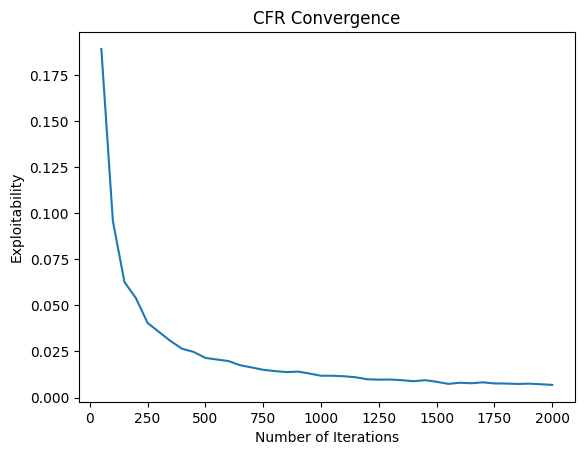

In [13]:
# convergence plot
plt.plot(range(LOG_EVERY, NUM_ITERATIONS+1, LOG_EVERY), exploitabilities)
plt.xlabel("Number of Iterations")
plt.ylabel("Exploitability")
plt.title("CFR Convergence")

In [14]:
# Show that when 2 bots following the average policy against each other, the expected return is close to 0 
# This shows that the average policy is close to a Nash equilibrium as it is a 0-sum game 

# create bot 
class SimpleBot:

    def __init__(self, policy, player_id): 
        self.policy = policy 
        self.player_id = player_id

    def step(self, state):
        """
        Given the state of the game, return an action to take, 
        selecting at random from the policy distribution.
        """
        action_probs = self.policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]

# let bots play against each other and output the average return for each one 
    
def simulate_game(n=500):
    bot1 = SimpleBot(average_policy, 0)
    bot2 = SimpleBot(average_policy, 1)
    returns = [0.0, 0.0]

    for _ in range(n):
        state = game.new_initial_state()
        while not state.is_terminal():
            if state.is_chance_node():
                outcomes, probs = zip(*state.chance_outcomes())
                action = random.choices(outcomes, weights=probs)[0]
            else:
                bot = bot1 if state.current_player() == 0 else bot2
                action = bot.step(state)
            state.apply_action(action)
        r = state.returns()
        returns[0] += r[0]
        returns[1] += r[1]

    print(f"After simulating {n} games: ")
    print(f"Bot 1 average return: {returns[0]/n:.4f}")
    print(f"Bot 2 average return: {returns[1]/n:.4f}")


simulate_game(10000)

After simulating 10000 games: 
Bot 1 average return: -0.0855
Bot 2 average return: 0.0855


average return close to 0 for both, so we are close to the Nash Equilibrium 

## COMPARISONS WITH OTHER CFR VARIANTS 

Regret Matching+ (RM+) truncates negative cumulative regrets to zero in each iteration

In [15]:
# CFR+ implementation 
game = pyspiel.load_game("leduc_poker(players=2)")
state = game.new_initial_state()
solver_cfr_plus = cfr.CFRPlusSolver(game)
exploitabilities_cfr_plus = []

for i in range(1, NUM_ITERATIONS+1):
    solver_cfr_plus.evaluate_and_update_policy()

    if i % LOG_EVERY == 0:
        avg_policy = solver_cfr_plus.average_policy()
        expl = exploitability.exploitability(game, avg_policy)
        print(f"CFR+ Iteration {i:>10}  Exploitability: {expl:>16.6f}")
        exploitabilities_cfr_plus.append(expl)

average_policy_cfr_plus = solver_cfr_plus.average_policy()
final_expl_cfr_plus = exploitability.exploitability(game, average_policy_cfr_plus)
print(f"\nFinal CFR+ exploitability after {NUM_ITERATIONS} iterations: {final_expl_cfr_plus:.6f}")

CFR+ Iteration         50  Exploitability:         0.034121
CFR+ Iteration        100  Exploitability:         0.013416
CFR+ Iteration        150  Exploitability:         0.007441
CFR+ Iteration        200  Exploitability:         0.004963
CFR+ Iteration        250  Exploitability:         0.003125
CFR+ Iteration        300  Exploitability:         0.002290
CFR+ Iteration        350  Exploitability:         0.001566
CFR+ Iteration        400  Exploitability:         0.001233
CFR+ Iteration        450  Exploitability:         0.001034
CFR+ Iteration        500  Exploitability:         0.000939
CFR+ Iteration        550  Exploitability:         0.000766
CFR+ Iteration        600  Exploitability:         0.000639
CFR+ Iteration        650  Exploitability:         0.000554
CFR+ Iteration        700  Exploitability:         0.000464
CFR+ Iteration        750  Exploitability:         0.000452
CFR+ Iteration        800  Exploitability:         0.000369
CFR+ Iteration        850  Exploitabilit

In [16]:
# CFR-BR implementation
game = pyspiel.load_game("leduc_poker(players=2)")
state = game.new_initial_state()
solver_cfr_br = cfr_br.CFRBRSolver(game)
exploitabilities_cfr_br = []

for i in range(1, NUM_ITERATIONS+1):
    solver_cfr_br.evaluate_and_update_policy()

    if i % LOG_EVERY == 0:
        avg_policy = solver_cfr_br.average_policy()
        expl = exploitability.exploitability(game, avg_policy)
        print(f"CFR-BR Iteration {i:>10}  Exploitability: {expl:>16.6f}")
        exploitabilities_cfr_br.append(expl)

average_policy_cfr_br = solver_cfr_br.average_policy()
final_expl_cfr_br = exploitability.exploitability(game, average_policy_cfr_br)
print(f"\nFinal CFR-BR exploitability after {NUM_ITERATIONS} iterations: {final_expl_cfr_br:.6f}")

CFR-BR Iteration         50  Exploitability:         0.299211
CFR-BR Iteration        100  Exploitability:         0.192727
CFR-BR Iteration        150  Exploitability:         0.146949
CFR-BR Iteration        200  Exploitability:         0.123138
CFR-BR Iteration        250  Exploitability:         0.106970
CFR-BR Iteration        300  Exploitability:         0.095795
CFR-BR Iteration        350  Exploitability:         0.087663
CFR-BR Iteration        400  Exploitability:         0.081458
CFR-BR Iteration        450  Exploitability:         0.076379
CFR-BR Iteration        500  Exploitability:         0.071991
CFR-BR Iteration        550  Exploitability:         0.068140
CFR-BR Iteration        600  Exploitability:         0.064903
CFR-BR Iteration        650  Exploitability:         0.061970
CFR-BR Iteration        700  Exploitability:         0.059467
CFR-BR Iteration        750  Exploitability:         0.057290
CFR-BR Iteration        800  Exploitability:         0.055346
CFR-BR I

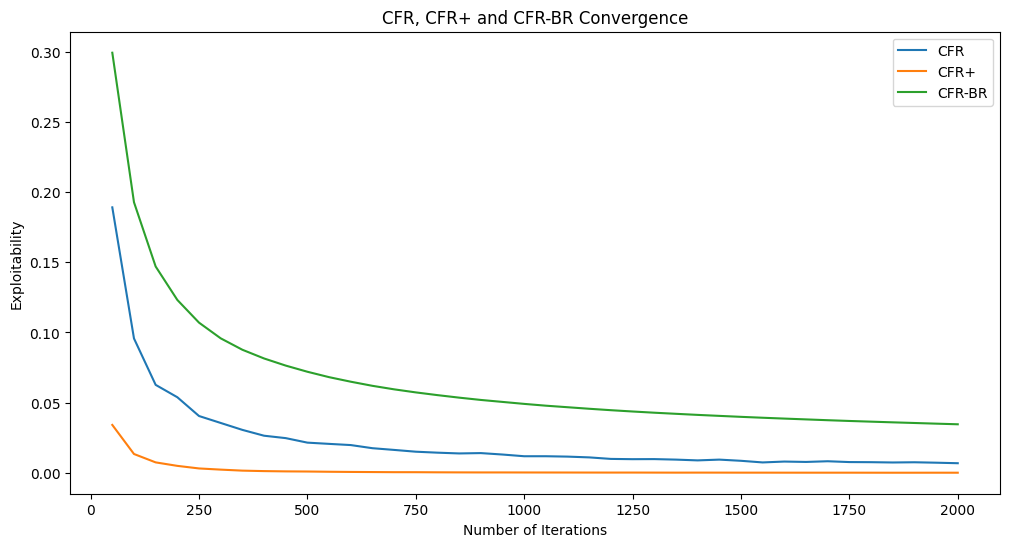

In [17]:
# convergence plot for all three algorithms
plt.figure(figsize=(12, 6))
plt.plot(range(LOG_EVERY, NUM_ITERATIONS+1, LOG_EVERY), exploitabilities, label="CFR")
plt.plot(range(LOG_EVERY, NUM_ITERATIONS+1, LOG_EVERY), exploitabilities_cfr_plus, label="CFR+")
plt.plot(range(LOG_EVERY, NUM_ITERATIONS+1, LOG_EVERY), exploitabilities_cfr_br, label="CFR-BR")
plt.xlabel("Number of Iterations")
plt.ylabel("Exploitability")
plt.title("CFR, CFR+ and CFR-BR Convergence")
plt.legend()

In [18]:
# inspect some states and their average policy for CFR+ (best one) to examine the learned strategy and ensure it makes sense 
def inspect_state(state, policy, label=""): 
    while state.is_chance_node():
        action, _ = state.chance_outcomes()[0] 
        state.apply_action(action)
    if state.is_terminal(): 
        return 
    probs = policy.action_probabilities(state)
    actions = state.legal_actions()
    print(f"\n{'─'*55}")
    if label:
        print(f"  Scenario  : {label}")
    print(f"  InfoState : {state.information_state_string()}")
    print(f"  Player    : {state.current_player()}")
    print(f"  Strategy  :")
    for a in actions:
        name = state.action_to_string(state.current_player(), a)
        print(f"    {name:<12}  {probs.get(a, 0):.4f}")


# Scenario 1: Inspect very first decision of the game 
inspect_state(game.new_initial_state(), average_policy_cfr_plus, label="Initial Decision (Player 0)")


───────────────────────────────────────────────────────
  Scenario  : Initial Decision (Player 0)
  InfoState : [Observer: 0][Private: 0][Round 1][Player: 0][Pot: 2][Money: 99 99][Round1: ][Round2: ]
  Player    : 0
  Strategy  :
    Call          0.9275
    Raise         0.0725


# Scenario 1
Expect him to call most of the times, since 0=jack, and bluff (raise) some times (call should be equal to not adding anything to ante)

In [19]:
# Scenario 2: Player 1 facing a raise with a queen in hand (round 1)
s3 = game.new_initial_state()
s3.apply_action(4) # player 0 gets a king
s3.apply_action(3) # player 1 gets a queen 
s3.apply_action(2) # player 0 raises  
inspect_state(s3, average_policy_cfr_plus,
              label="Player 1 facing a raise with strong hand (round 1)")



───────────────────────────────────────────────────────
  Scenario  : Player 1 facing a raise with strong hand (round 1)
  InfoState : [Observer: 1][Private: 3][Round 1][Player: 1][Pot: 4][Money: 97 99][Round1: 2][Round2: ]
  Player    : 1
  Strategy  :
    Fold          0.0001
    Call          0.6285
    Raise         0.3714


# Scenario 2 
Player 1 has private card 1=Queen, expect to fold most of times, as player 0 with 0=Jack he will raise only sporadically, so we can expect him to raise more when he has a strong hand (a king)

how each card is written: 0 J1, 1 J2, 2 Q1, 3 Q2, 4 K1, 5 K2

In [20]:
s4 = game.new_initial_state()
s4.apply_action(0) # player 0 gets a jack
s4.apply_action(3) # player 1 gets a queen 
s4.apply_action(2) # player 0 raises  
inspect_state(s4, average_policy_cfr_plus,
              label="Player 1 facing a raise with strong hand (round 1)")



───────────────────────────────────────────────────────
  Scenario  : Player 1 facing a raise with strong hand (round 1)
  InfoState : [Observer: 1][Private: 3][Round 1][Player: 1][Pot: 4][Money: 97 99][Round1: 2][Round2: ]
  Player    : 1
  Strategy  :
    Fold          0.0001
    Call          0.6285
    Raise         0.3714


sanity check, that no matter actual hand of player 0, player 1 still follow same policy (since cannot see player0's cards)